In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

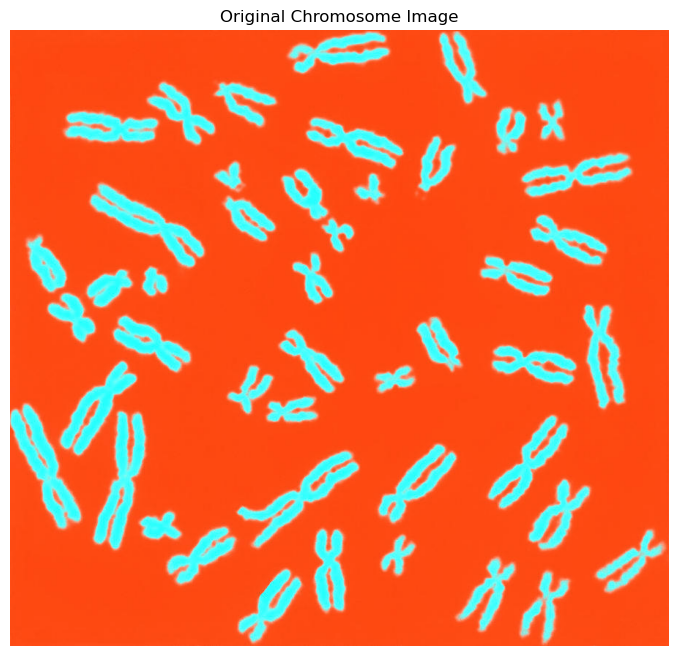

In [94]:
img=cv2.imread('Chromosomes.jpg')
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.title('Original Chromosome Image')
plt.axis('off') 
plt.show()

Text(0.5, 1.0, 'RBG Chromosome Image')

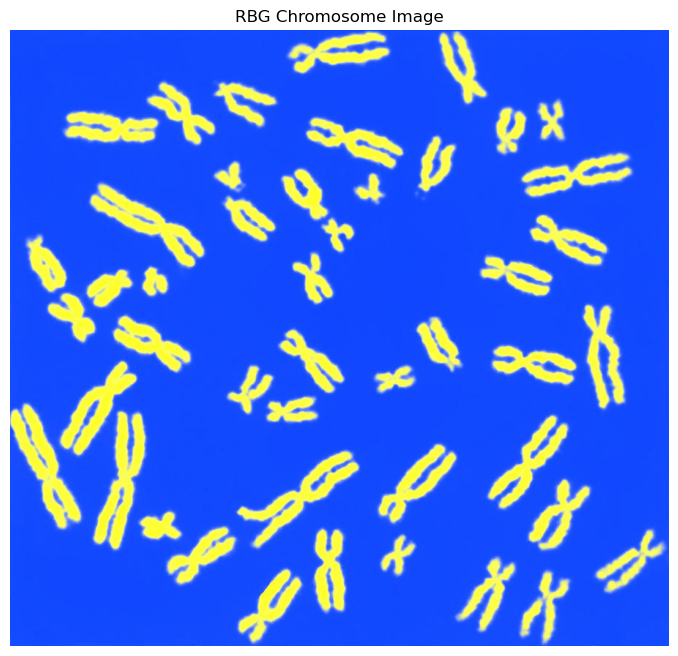

In [96]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.axis('off') 
plt.title('RBG Chromosome Image')


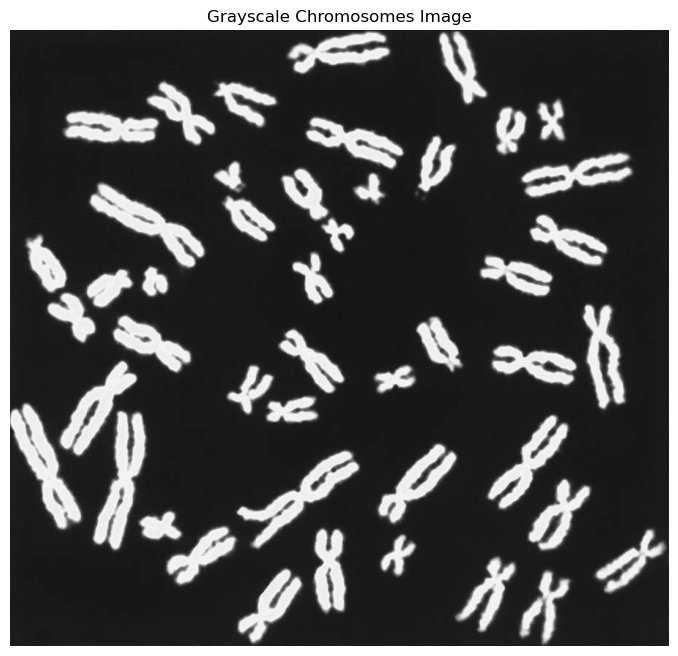

In [98]:
gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(10, 8))
plt.imshow(gray_image, cmap='gray') 
plt.title('Grayscale Chromosomes Image')
plt.axis('off')
plt.show()

Total Chromosomes Detected: 46


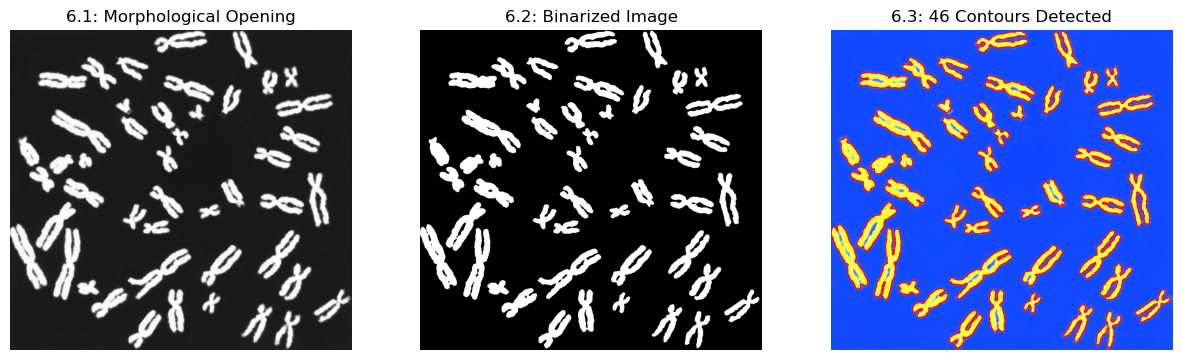

In [100]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5)) 
morph_image = cv2.morphologyEx(gray_image, cv2.MORPH_OPEN, kernel)
ret, thresh = cv2.threshold(morph_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

num_chromosomes = len(contours)
print(f"Total Chromosomes Detected: {num_chromosomes}")

# --- Visualization for Step 6 ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(morph_image, cmap='gray')
plt.title('6.1: Morphological Opening')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(thresh, cmap='gray')
plt.title('6.2: Binarized Image')
plt.axis('off')

plt.subplot(1, 3, 3)
contour_img = img_rgb.copy()
cv2.drawContours(contour_img, contours, -1, (255, 0, 0), 2)
plt.imshow(contour_img)
plt.title(f'6.3: {num_chromosomes} Contours Detected')
plt.axis('off')

plt.show()

In [50]:
print(kernel)

[[0 0 1 0 0]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [0 0 1 0 0]]


### Features and Bounding:


Extracted Chromosome Features:
    Height  Width      Area  Perimeter  Circularity
0       98     67 2170.0000   415.7056       0.1578
1      101     86 3097.0000   443.8721       0.1975
2      101     80 2526.5000   437.0021       0.1663
3       55     46 1010.0000   216.6518       0.2704
4       86     92 2279.5000   440.8011       0.1474
5      113     43 3471.5000   370.1493       0.3184
6       79     94 2966.0000   359.5046       0.2884
7       38     57 1328.5000   182.7523       0.4999
8       97     84 2921.0000   464.9016       0.1698
9      133    167 5454.0000   619.2102       0.1788
10     108    107 3687.5000   499.3696       0.1858
11     127    109 3916.0000   607.2102       0.1335
12     189     71 5730.0000   694.0732       0.1495
13     171     97 6034.0000   474.4163       0.3369
14      35     69 1504.5000   268.8944       0.2615
15      37     54 1009.5000   197.5807       0.3250
16      66     62 1481.0000   268.9361       0.2573
17     129    105 4792.5000   38

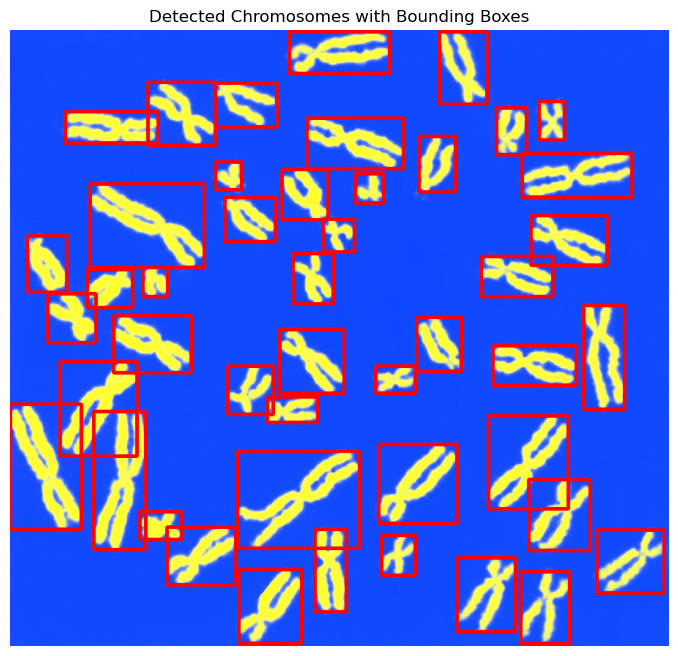

In [131]:
threshold = 5

if len(contours) >= threshold:
    features = []
    rgb_img = img_rgb.copy()

    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(rgb_img, (x, y), (x + w, y + h), (255, 0, 0), 4)

        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)

        circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0

        features.append({
            "Height": h,
            "Width": w,
            "Area": area,
            "Perimeter": perimeter,
            "Circularity": circularity
        })

    data = pd.DataFrame(features)
    print("\nExtracted Chromosome Features:")
    print(data)

    # Show bounding boxes
    plt.figure(figsize=(10, 8))
    plt.imshow(rgb_img)
    plt.title('Detected Chromosomes with Bounding Boxes')
    plt.axis('off')
    plt.show()

else:
    print("Insufficient contours detected. Exiting.")

### Standardized and Normalized Data

In [133]:
standardized_features = (data - data.mean()) / data.std()
print("Standardized Features:")
print(standardized_features)
print('\n')

# Normalization (Min-Max Scaling)
normalized_features = (data - data.min()) / (data.max() - data.min())
print("Normalized Features:")
print(normalized_features)

Standardized Features:
    Height   Width    Area  Perimeter  Circularity
0   0.5229 -0.4013 -0.3519     0.3510      -0.9229
1   0.6079  0.1599  0.3323     0.5420      -0.6498
2   0.6079 -0.0173 -0.0888     0.4954      -0.8648
3  -0.6967 -1.0215 -1.2081    -0.9985      -0.1488
4   0.1825  0.3371 -0.2711     0.5212      -0.9943
5   0.9483 -1.1101  0.6087     0.0422       0.1812
6  -0.0160  0.3961  0.2356    -0.0300      -0.0251
7  -1.1789 -0.6966 -0.9731    -1.2284       1.4287
8   0.4945  0.1008  0.2024     0.6846      -0.8402
9   1.5155  2.5522  2.0720     1.7307      -0.7789
10  0.8065  0.7801  0.7682     0.9183      -0.7303
11  1.3454  0.8392  0.9368     1.6494      -1.0902
12  3.1038 -0.2831  2.2757     2.2383      -0.9802
13  2.5933  0.4847  2.5001     0.7491       0.3084
14 -1.2640 -0.3422 -0.8432    -0.6443      -0.2101
15 -1.2072 -0.7852 -1.2085    -1.1278       0.2263
16 -0.3847 -0.5490 -0.8605    -0.6441      -0.2387
17  1.4021  0.7210  1.5838     0.1611       0.7469
18 -0.72

# Report

### Q1: How can contour detection be used to identify objects in an image?
Ans : Contour detection is used to identify the objects by detecting and highlight the boundaries of each object in the image.It is based on changes in pixel intensity.Therefore, any change in the pixel intensity leads to edge detection. There are many characteristics/features of an object like height, width, perimeter, area and circularity, which can be identified through contour detection.

### Q2:What is the importance of standardization of data? What difference did you observe before and after standardization?
Ans: Standardization or (Z-scoring)  is used for feature scaling, ensuring that all features are on a similar scale, which enables the machine learning model to train more effectively. It works well for data that follows a normal (Gaussian) distribution and is less affected by outliers. Standardization transforms the data so that it has a mean of 0 and a standard deviation of 1. After standardization, features such as area, perimeter, and circularity become more comparable because they are lying to the same scale, which removes bias caused by different feature ranges.

### Q3:Let’s consider that one of the values in the width column is missing. How to handle this missing value?
Ans :Using Regression /interpolation is the best way for filling missing data;It is not good to use any one of central tendencies like mean median or mode because presence of any outlier can ruin the data

### Q4:What is the importance of data normalization? What difference did you observe before and after normalization?
Ans:Normalization is a feature scaling method used to bring all features to the same range so that a machine learning model can learn properly. It scales the values between 0 and 1, which is useful when the data does not follow a normal distribution. Before normalization, some features have a different range of values(some having high and some low). With normalization, all features comes within the range of 0 to 1, making them easier to compare and reducing bias caused by different scales.

### Q5:How might you adapt the bounding box construction process to handle overlapping or touching chromosomes?
Ans:To separate touching/overlapping chromosomes in an image, we can use morphological operations such as erosion, dilation, and opening. Erosion helps by shrinking the chromosomes, which can separate that are touching each other. Dilation is then used to grow the chromosomes back to their original size. Opening is a combination of erosion followed by dilation, and it is very effective because it separates touching chromosomes while preserving their overall shape.